# 🏥 Healthcare Funding Analytics
## Activity Based Funding · Own Source Revenue · National Funding Arrangements

**Author:** Chethana Manjunath  
**Tools:** Python · Pandas · Matplotlib · Seaborn · NumPy  
**Dataset:** Simulated Queensland public hospital funding data (14 HHS · 2019–2024)

---

### Project Objectives
1. Analyse **Activity Based Funding (ABF)** — NWA volumes, prices, funded amounts, and cost variances by HHS and care type
2. Analyse **Own Source Revenue (OSR)** — revenue trends, COVID-19 impact, category performance, and budget variance
3. Analyse **National Funding Arrangements (NFA)** — Commonwealth vs State funding split, stream utilisation, and allocation trends
4. Build a **consolidated funding dashboard** comparing all three streams across HHS
5. Export **Power BI-ready tables** for dashboard visualisation

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0c10', 'axes.facecolor': '#111318',
    'axes.edgecolor': '#1e2330', 'axes.labelcolor': '#8892a4',
    'xtick.color': '#8892a4', 'ytick.color': '#8892a4',
    'text.color': '#f0f4ff', 'grid.color': '#1e2330',
    'grid.linestyle': '--', 'font.family': 'monospace',
    'legend.facecolor': '#111318', 'legend.labelcolor': '#f0f4ff',
})
CYAN='#00d4ff'; PURPLE='#7c3aed'; GREEN='#10b981'
ORANGE='#f59e0b'; RED='#ef4444'; PINK='#ec4899'
COLORS = [CYAN, PURPLE, GREEN, ORANGE, RED, PINK, '#3b82f6', '#84cc16']

NQ_HHS = ['Cairns and Hinterland','Townsville','Mackay','North West','Torres and Cape']
METRO  = ['Metro North','Metro South','Gold Coast','Sunshine Coast']

# ── Load data ──────────────────────────────────────────────────
abf     = pd.read_csv('../data/abf_data.csv')
osr     = pd.read_csv('../data/osr_data.csv')
nfa     = pd.read_csv('../data/nfa_data.csv')
summary = pd.read_csv('../data/funding_summary.csv')

print(f'ABF rows:     {len(abf):,}')
print(f'OSR rows:     {len(osr):,}')
print(f'NFA rows:     {len(nfa):,}')
print(f'Summary rows: {len(summary):,}')
print(f'\nYears covered: {sorted(abf.Year.unique())}')
print(f'HHS count: {abf.HHS.nunique()}')

ABF rows:     2,016
OSR rows:     3,024
NFA rows:     588
Summary rows: 84

Years covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
HHS count: 14


## 2. Activity Based Funding (ABF) Analysis

### 2.1 Total ABF Funding by HHS (2024)

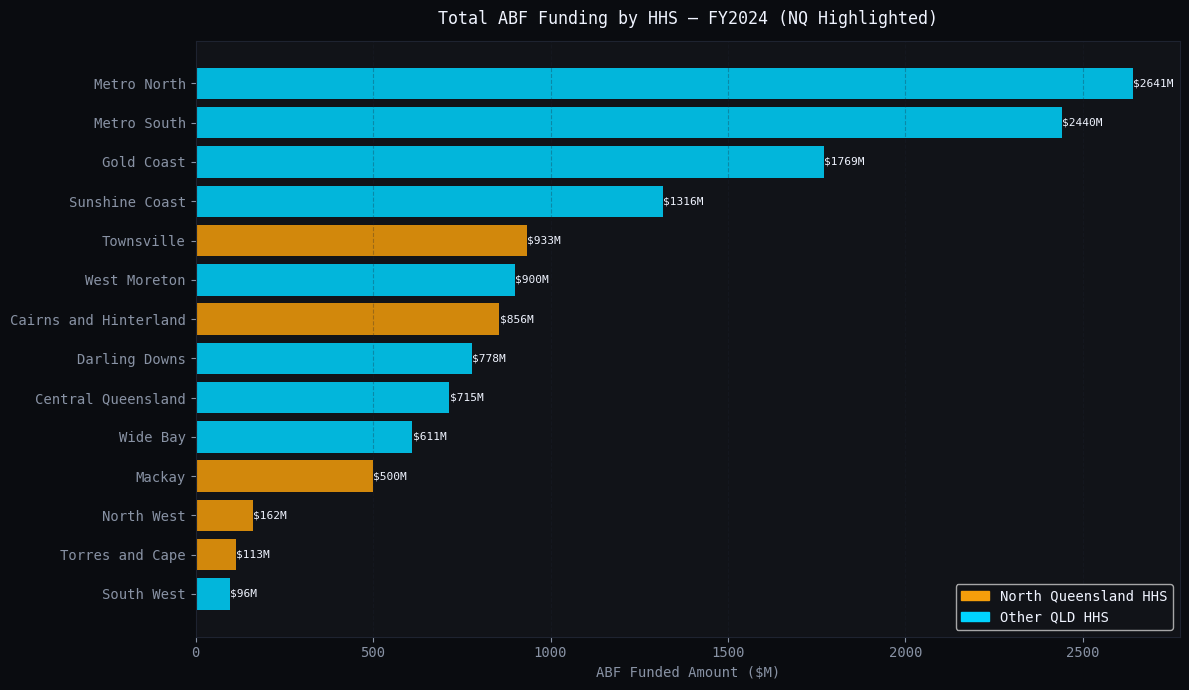

In [2]:
abf_2024 = abf[abf['Year']==2024].groupby('HHS')['ABF_Funded_Amt'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [ORANGE if h in NQ_HHS else CYAN for h in abf_2024.index]
bars = ax.barh(abf_2024.index, abf_2024.values/1e6, color=colors, alpha=0.85)
for bar, val in zip(bars, abf_2024.values/1e6):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'${val:.0f}M', va='center', fontsize=8)
ax.set_title('Total ABF Funding by HHS — FY2024 (NQ Highlighted)', pad=12)
ax.set_xlabel('ABF Funded Amount ($M)')
ax.legend(handles=[Patch(color=ORANGE,label='North Queensland HHS'),
                   Patch(color=CYAN,label='Other QLD HHS')], loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/chart_abf_by_hhs.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

### 2.2 ABF Funding Trend 2019–2024 (NQ vs Metro)

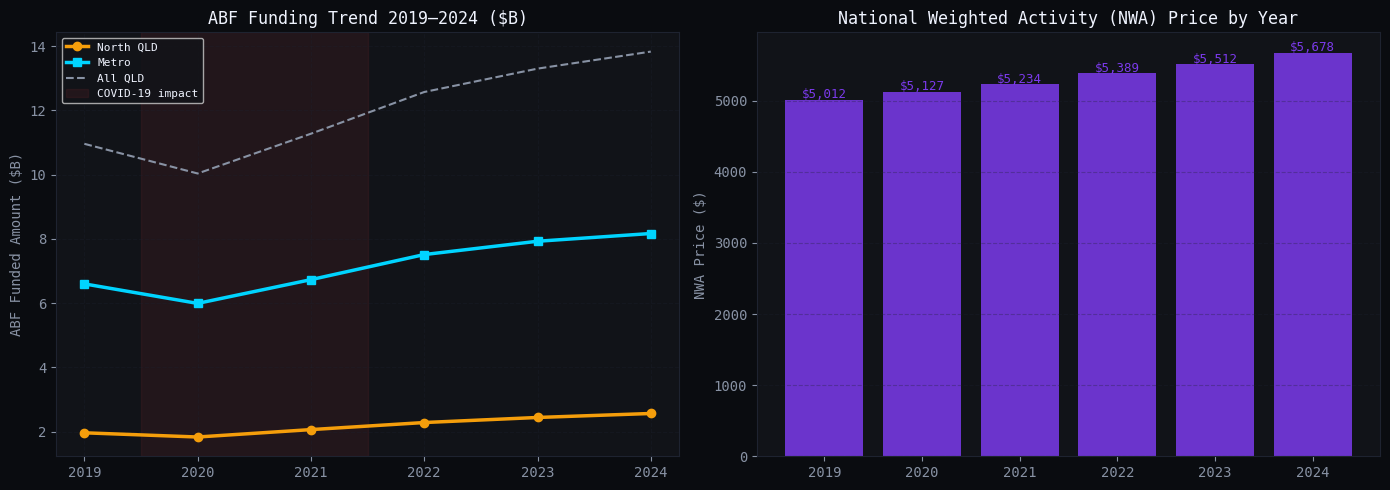

In [3]:
abf_trend = abf.groupby(['Year','HHS'])['ABF_Funded_Amt'].sum().reset_index()
nq_trend   = abf_trend[abf_trend['HHS'].isin(NQ_HHS)].groupby('Year')['ABF_Funded_Amt'].sum()
metro_trend = abf_trend[abf_trend['HHS'].isin(METRO)].groupby('Year')['ABF_Funded_Amt'].sum()
qld_trend   = abf_trend.groupby('Year')['ABF_Funded_Amt'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trend lines
axes[0].plot(nq_trend.index, nq_trend.values/1e9, color=ORANGE, linewidth=2.5, marker='o', label='North QLD')
axes[0].plot(metro_trend.index, metro_trend.values/1e9, color=CYAN, linewidth=2.5, marker='s', label='Metro')
axes[0].plot(qld_trend.index, qld_trend.values/1e9, color='#8892a4', linewidth=1.5, linestyle='--', label='All QLD')
axes[0].axvspan(2019.5, 2021.5, alpha=0.08, color=RED, label='COVID-19 impact')
axes[0].set_title('ABF Funding Trend 2019–2024 ($B)')
axes[0].set_ylabel('ABF Funded Amount ($B)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# NWA price growth
prices = abf.groupby('Year')['NWA_Price'].mean()
axes[1].bar(prices.index, prices.values, color=PURPLE, alpha=0.85)
for x, y in zip(prices.index, prices.values):
    axes[1].text(x, y+20, f'${y:,.0f}', ha='center', fontsize=9, color=PURPLE)
axes[1].set_title('National Weighted Activity (NWA) Price by Year')
axes[1].set_ylabel('NWA Price ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/chart_abf_trend.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

### 2.3 ABF Cost Variance by Care Type

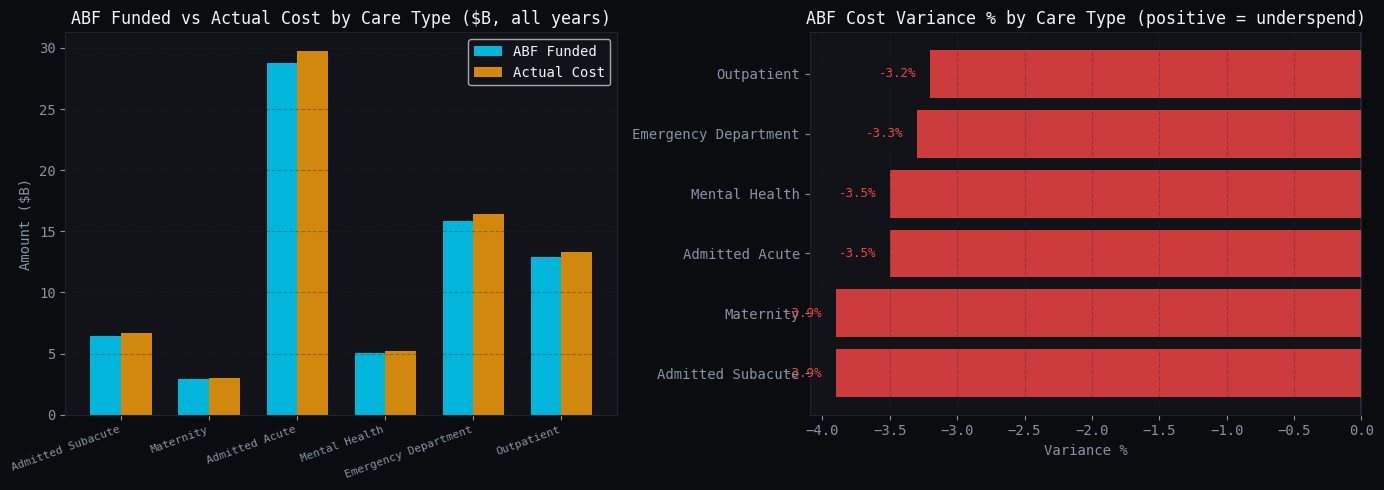


ABF Cost Variance Summary by Care Type:
           Care_Type       Funded       Actual     Variance  Variance_Pct
   Admitted Subacute 6.437816e+09 6.689234e+09 -251418188.0          -3.9
           Maternity 2.884307e+09 2.995782e+09 -111474956.0          -3.9
      Admitted Acute 2.879172e+10 2.978693e+10 -995217146.0          -3.5
       Mental Health 5.056778e+09 5.235230e+09 -178451841.0          -3.5
Emergency Department 1.586592e+10 1.638586e+10 -519939221.0          -3.3
          Outpatient 1.292934e+10 1.334559e+10 -416249260.0          -3.2


In [4]:
variance_care = abf.groupby('Care_Type').agg(
    Funded=('ABF_Funded_Amt','sum'),
    Actual=('Actual_Cost','sum'),
    Variance=('Variance','sum')
).reset_index()
variance_care['Variance_Pct'] = (variance_care['Variance'] / variance_care['Funded'] * 100).round(1)
variance_care = variance_care.sort_values('Variance_Pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Funded vs Actual
x = np.arange(len(variance_care))
w = 0.35
axes[0].bar(x-w/2, variance_care['Funded']/1e9, w, color=CYAN, alpha=0.85, label='ABF Funded')
axes[0].bar(x+w/2, variance_care['Actual']/1e9, w, color=ORANGE, alpha=0.85, label='Actual Cost')
axes[0].set_xticks(x)
axes[0].set_xticklabels(variance_care['Care_Type'], rotation=20, ha='right', fontsize=8)
axes[0].set_title('ABF Funded vs Actual Cost by Care Type ($B, all years)')
axes[0].set_ylabel('Amount ($B)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Variance %
colors_var = [GREEN if v>=0 else RED for v in variance_care['Variance_Pct']]
axes[1].barh(variance_care['Care_Type'], variance_care['Variance_Pct'], color=colors_var, alpha=0.85)
axes[1].axvline(0, color='#8892a4', linewidth=1)
for i,(_, row) in enumerate(variance_care.iterrows()):
    axes[1].text(row['Variance_Pct']+(0.1 if row['Variance_Pct']>=0 else -0.1),
                 i, f"{row['Variance_Pct']:+.1f}%", va='center', fontsize=9,
                 ha='left' if row['Variance_Pct']>=0 else 'right',
                 color=GREEN if row['Variance_Pct']>=0 else RED)
axes[1].set_title('ABF Cost Variance % by Care Type (positive = underspend)')
axes[1].set_xlabel('Variance %')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/chart_abf_variance.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

print('\nABF Cost Variance Summary by Care Type:')
print(variance_care[['Care_Type','Funded','Actual','Variance','Variance_Pct']].to_string(index=False))

## 3. Own Source Revenue (OSR) Analysis

### 3.1 OSR Trend & COVID Impact

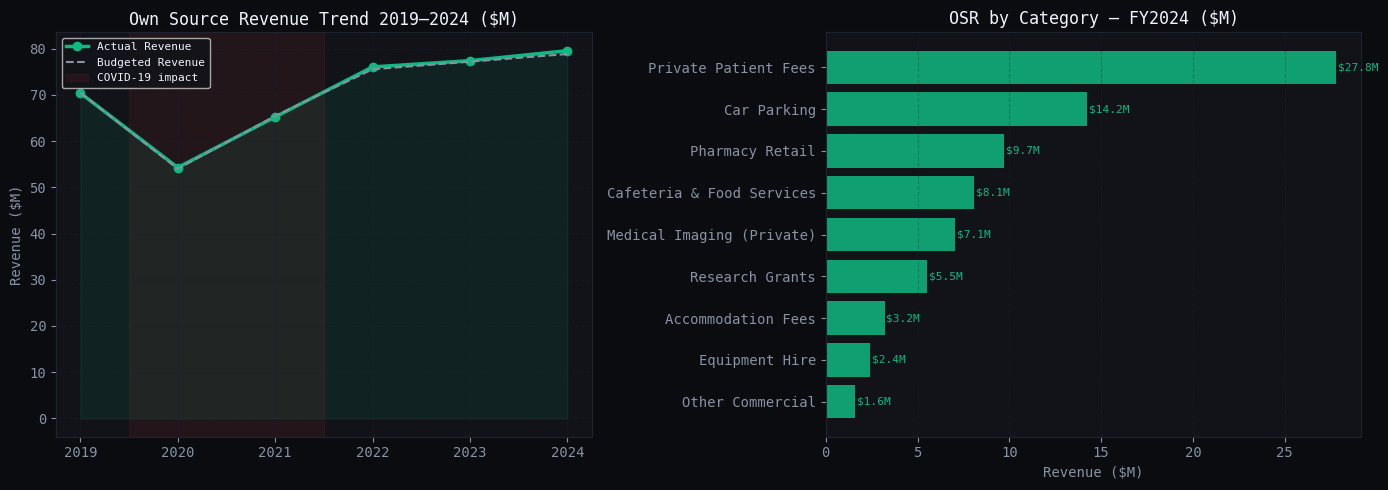

In [5]:
osr_trend = osr.groupby('Year')['Actual_Revenue'].sum().reset_index()
osr_budget = osr.groupby('Year')['Budgeted_Revenue'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Budget trend
axes[0].plot(osr_trend['Year'], osr_trend['Actual_Revenue']/1e6, color=GREEN, linewidth=2.5, marker='o', label='Actual Revenue')
axes[0].plot(osr_budget['Year'], osr_budget['Budgeted_Revenue']/1e6, color='#8892a4', linewidth=1.5, linestyle='--', label='Budgeted Revenue')
axes[0].fill_between(osr_trend['Year'], osr_trend['Actual_Revenue']/1e6, alpha=0.1, color=GREEN)
axes[0].axvspan(2019.5, 2021.5, alpha=0.08, color=RED, label='COVID-19 impact')
axes[0].set_title('Own Source Revenue Trend 2019–2024 ($M)')
axes[0].set_ylabel('Revenue ($M)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# OSR by category (2024)
osr_cat = osr[osr['Year']==2024].groupby('Category')['Actual_Revenue'].sum().sort_values(ascending=True)
axes[1].barh(osr_cat.index, osr_cat.values/1e6, color=GREEN, alpha=0.85)
for i,(cat,val) in enumerate(osr_cat.items()):
    axes[1].text(val/1e6+0.1, i, f'${val/1e6:.1f}M', va='center', fontsize=8, color=GREEN)
axes[1].set_title('OSR by Category — FY2024 ($M)')
axes[1].set_xlabel('Revenue ($M)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/chart_osr_trend.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

### 3.2 OSR Budget Variance by HHS

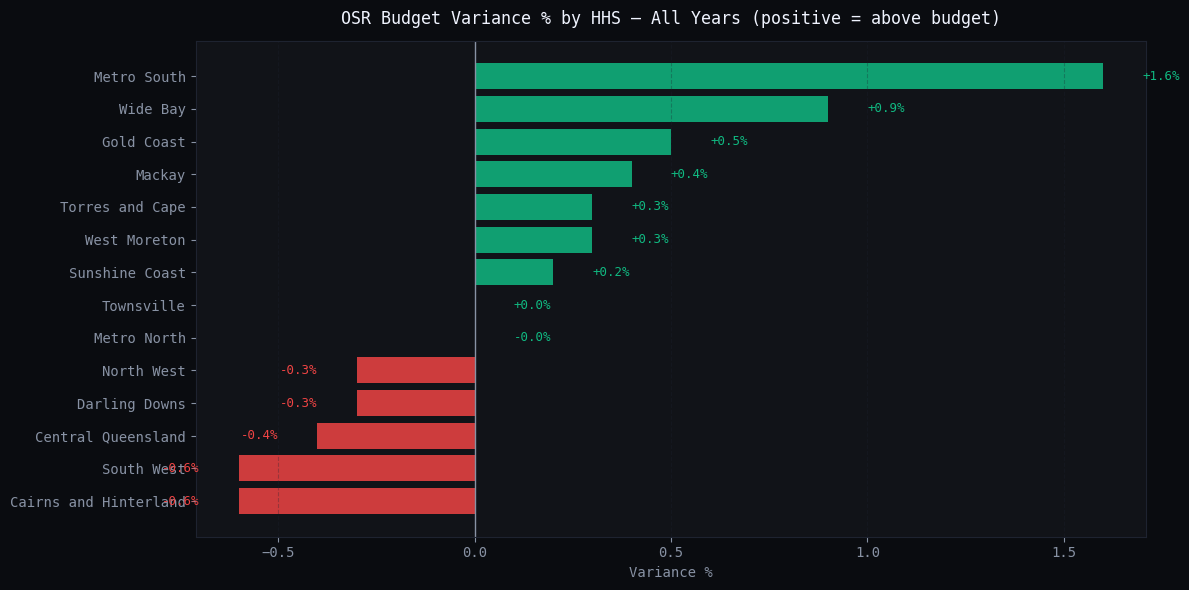

In [6]:
osr_hhs = osr.groupby('HHS').agg(
    Actual=('Actual_Revenue','sum'),
    Budget=('Budgeted_Revenue','sum')
).reset_index()
osr_hhs['Variance_Pct'] = ((osr_hhs['Actual'] - osr_hhs['Budget']) / osr_hhs['Budget'] * 100).round(1)
osr_hhs = osr_hhs.sort_values('Variance_Pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors_v = [GREEN if v>=0 else RED for v in osr_hhs['Variance_Pct']]
bars = ax.barh(osr_hhs['HHS'], osr_hhs['Variance_Pct'], color=colors_v, alpha=0.85)
ax.axvline(0, color='#8892a4', linewidth=1)
for bar, val in zip(bars, osr_hhs['Variance_Pct']):
    ax.text(val+(0.1 if val>=0 else -0.1), bar.get_y()+bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=9,
            ha='left' if val>=0 else 'right',
            color=GREEN if val>=0 else RED)
ax.set_title('OSR Budget Variance % by HHS — All Years (positive = above budget)', pad=12)
ax.set_xlabel('Variance %')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/chart_osr_variance.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

## 4. National Funding Arrangements (NFA) Analysis

### 4.1 Commonwealth vs State Funding Split Over Time

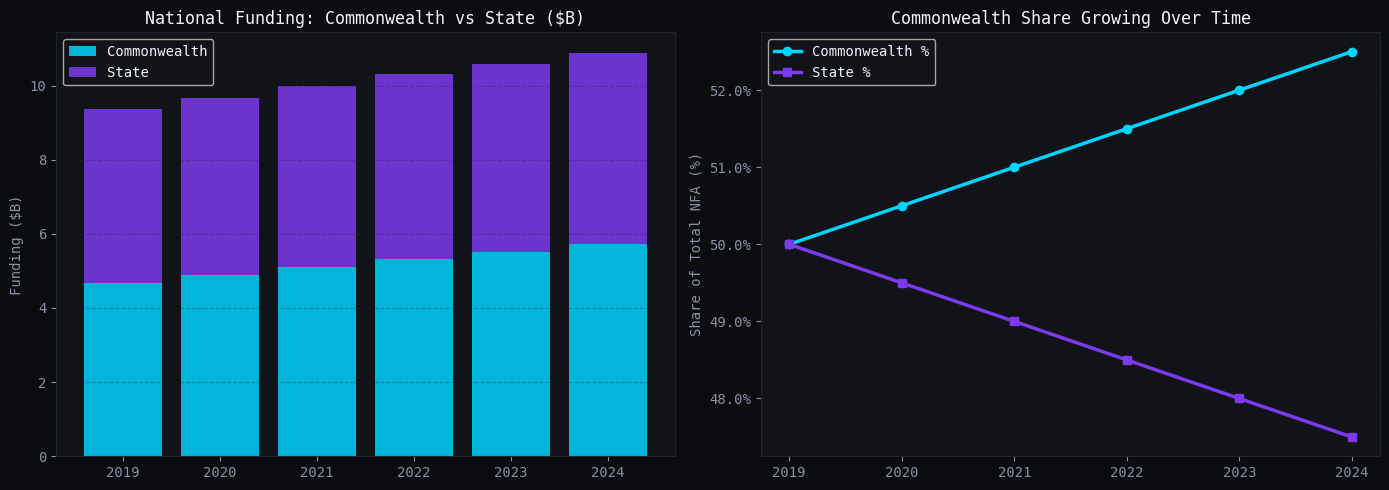


NFA Split Summary:
 Year  Commonwealth        State        Total  Cwth_Pct
 2019  4687051212.0 4687051212.0 9.374102e+09      50.0
 2020  4886499875.0 4789737508.0 9.676237e+09      50.5
 2021  5092662298.0 4892950048.0 9.985612e+09      51.0
 2022  5309772985.0 5000465830.0 1.031024e+10      51.5
 2023  5506633945.0 5083046720.0 1.058968e+10      52.0
 2024  5717719733.0 5173174998.0 1.089089e+10      52.5


In [7]:
nfa_split = nfa.groupby('Year').agg(
    Commonwealth=('Commonwealth_Share','sum'),
    State=('State_Share','sum'),
    Total=('Total_Allocation','sum')
).reset_index()
nfa_split['Cwth_Pct'] = (nfa_split['Commonwealth'] / nfa_split['Total'] * 100).round(1)
nfa_split['State_Pct'] = (nfa_split['State'] / nfa_split['Total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
axes[0].bar(nfa_split['Year'], nfa_split['Commonwealth']/1e9, color=CYAN, alpha=0.85, label='Commonwealth')
axes[0].bar(nfa_split['Year'], nfa_split['State']/1e9, bottom=nfa_split['Commonwealth']/1e9, color=PURPLE, alpha=0.85, label='State')
axes[0].set_title('National Funding: Commonwealth vs State ($B)')
axes[0].set_ylabel('Funding ($B)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Share trend
axes[1].plot(nfa_split['Year'], nfa_split['Cwth_Pct'], color=CYAN, linewidth=2.5, marker='o', label='Commonwealth %')
axes[1].plot(nfa_split['Year'], nfa_split['State_Pct'], color=PURPLE, linewidth=2.5, marker='s', label='State %')
axes[1].set_title('Commonwealth Share Growing Over Time')
axes[1].set_ylabel('Share of Total NFA (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/chart_nfa_split.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

print('\nNFA Split Summary:')
print(nfa_split[['Year','Commonwealth','State','Total','Cwth_Pct']].to_string(index=False))

### 4.2 NFA Stream Utilisation & Undrawn Funds

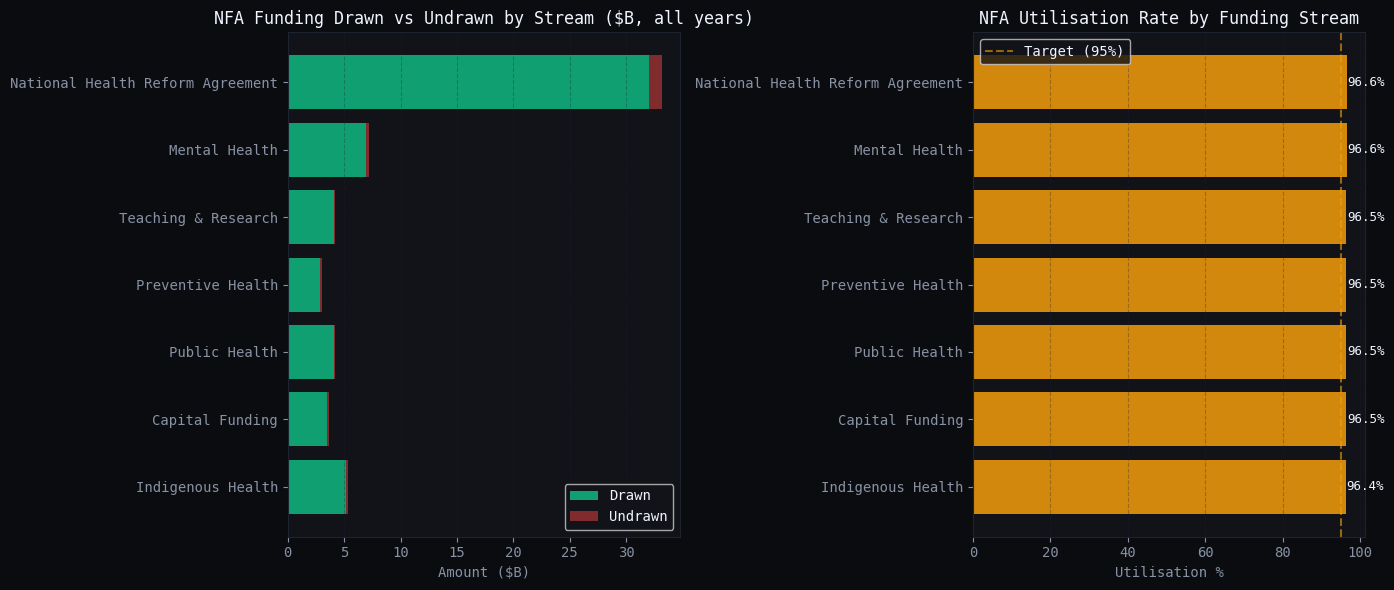

In [8]:
nfa_stream = nfa.groupby('Funding_Stream').agg(
    Allocation=('Total_Allocation','sum'),
    Drawn=('Amount_Drawn','sum'),
    Undrawn=('Amount_Undrawn','sum')
).reset_index()
nfa_stream['Utilisation_Pct'] = (nfa_stream['Drawn'] / nfa_stream['Allocation'] * 100).round(1)
nfa_stream = nfa_stream.sort_values('Utilisation_Pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Drawn vs Undrawn
axes[0].barh(nfa_stream['Funding_Stream'], nfa_stream['Drawn']/1e9, color=GREEN, alpha=0.85, label='Drawn')
axes[0].barh(nfa_stream['Funding_Stream'], nfa_stream['Undrawn']/1e9,
             left=nfa_stream['Drawn']/1e9, color=RED, alpha=0.5, label='Undrawn')
axes[0].set_title('NFA Funding Drawn vs Undrawn by Stream ($B, all years)')
axes[0].set_xlabel('Amount ($B)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Utilisation rate
util_colors = [GREEN if u>=97 else ORANGE if u>=94 else RED for u in nfa_stream['Utilisation_Pct']]
bars = axes[1].barh(nfa_stream['Funding_Stream'], nfa_stream['Utilisation_Pct'], color=util_colors, alpha=0.85)
axes[1].axvline(95, color=ORANGE, linestyle='--', alpha=0.6, label='Target (95%)')
for bar, val in zip(bars, nfa_stream['Utilisation_Pct']):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('NFA Utilisation Rate by Funding Stream')
axes[1].set_xlabel('Utilisation %')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/chart_nfa_utilisation.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

### 4.3 Indigenous Health Funding — NQ Focus

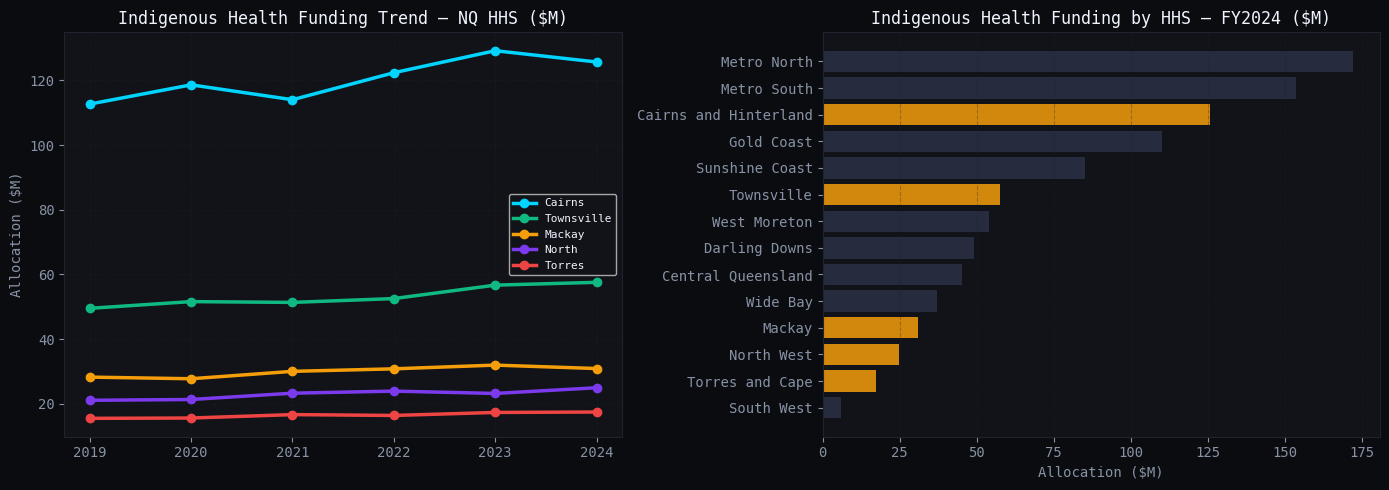

In [9]:
indigenous = nfa[nfa['Funding_Stream']=='Indigenous Health'].groupby(['HHS','Year'])['Total_Allocation'].sum().reset_index()
nq_ind = indigenous[indigenous['HHS'].isin(NQ_HHS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NQ Indigenous funding trend
nq_colors = [CYAN, GREEN, ORANGE, PURPLE, RED]
for i, hhs in enumerate(NQ_HHS):
    sub = nq_ind[nq_ind['HHS']==hhs]
    axes[0].plot(sub['Year'], sub['Total_Allocation']/1e6, marker='o', linewidth=2.5,
                 color=nq_colors[i], label=hhs.split()[0])
axes[0].set_title('Indigenous Health Funding Trend — NQ HHS ($M)')
axes[0].set_ylabel('Allocation ($M)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# All HHS Indigenous funding 2024
ind_2024 = indigenous[indigenous['Year']==2024].sort_values('Total_Allocation', ascending=True)
bar_colors = [ORANGE if h in NQ_HHS else '#2a3044' for h in ind_2024['HHS']]
axes[1].barh(ind_2024['HHS'], ind_2024['Total_Allocation']/1e6, color=bar_colors, alpha=0.85)
axes[1].set_title('Indigenous Health Funding by HHS — FY2024 ($M)')
axes[1].set_xlabel('Allocation ($M)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/chart_indigenous_funding.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

## 5. Consolidated Funding Dashboard

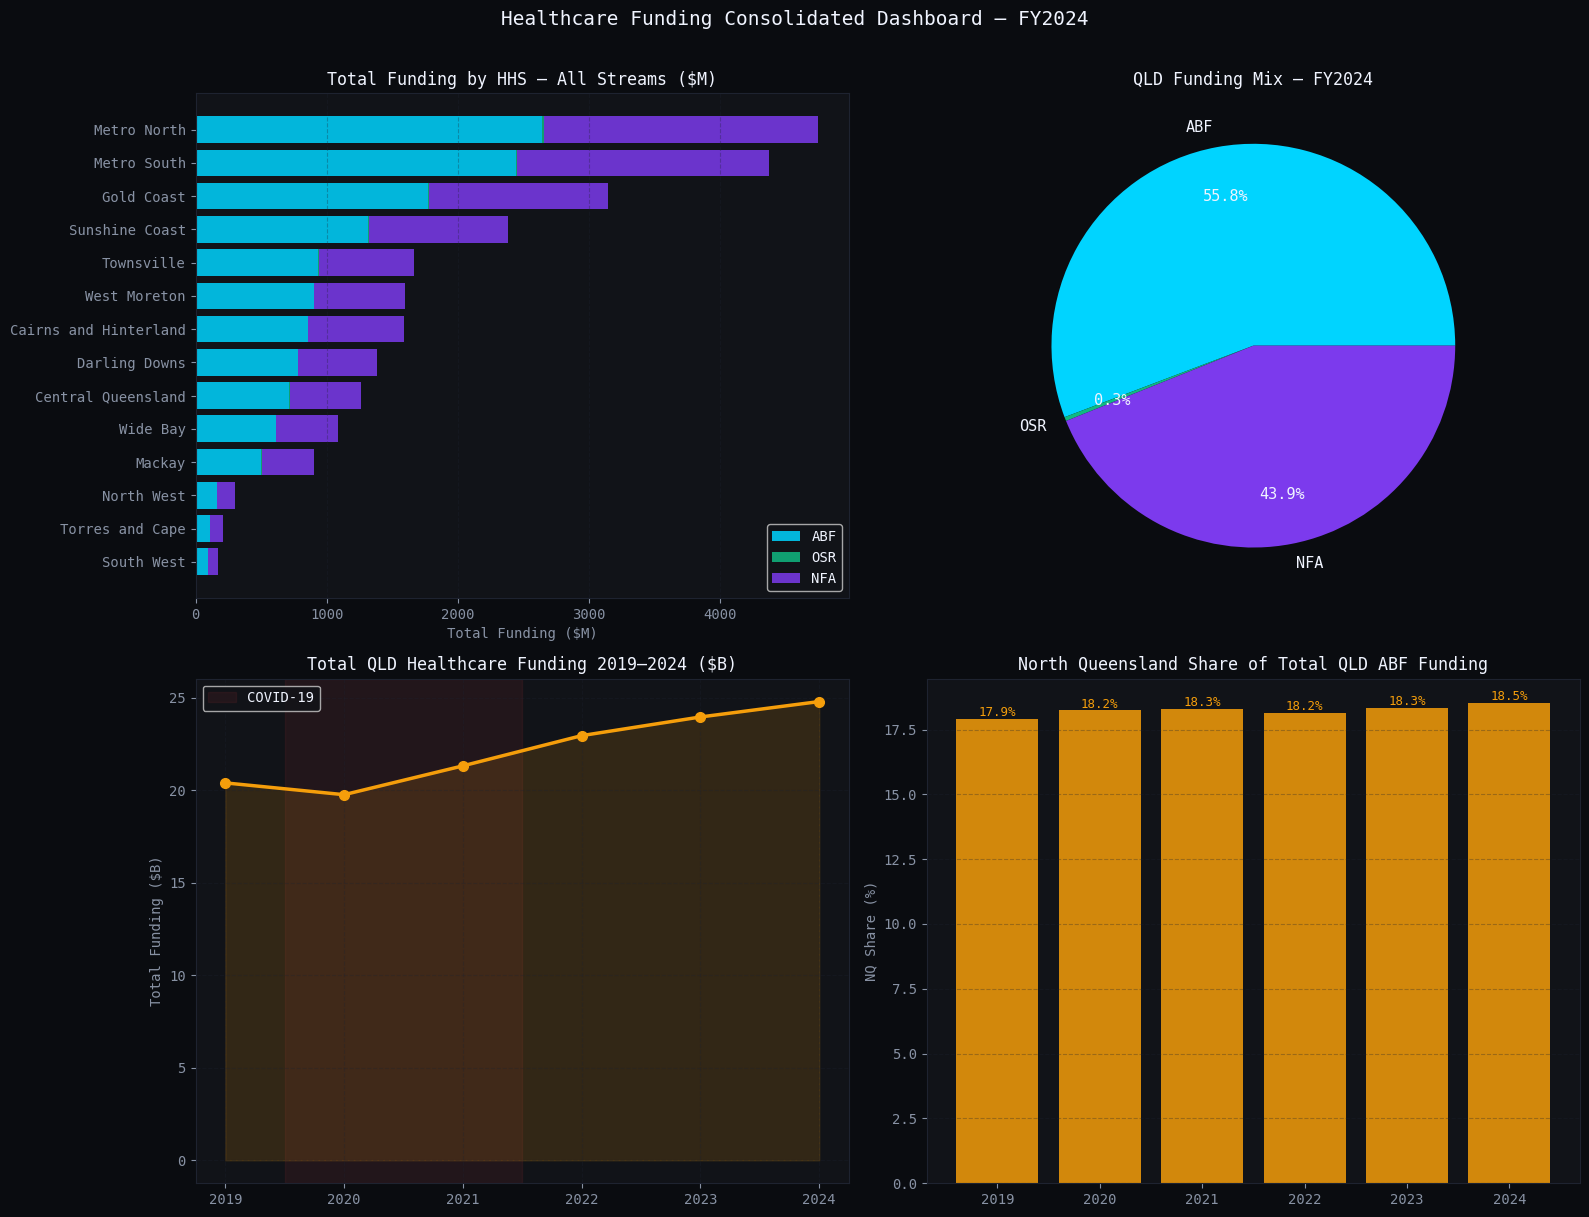

In [10]:
# Total funding by stream and year
sum_2024 = summary[summary['Year']==2024].sort_values('Total_Funding', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Healthcare Funding Consolidated Dashboard — FY2024', fontsize=14, color='#f0f4ff', y=1.01)

# Top left: Stacked bar by HHS
axes[0,0].barh(sum_2024['HHS'], sum_2024['ABF_Total']/1e6, color=CYAN, alpha=0.85, label='ABF')
axes[0,0].barh(sum_2024['HHS'], sum_2024['OSR_Total']/1e6, left=sum_2024['ABF_Total']/1e6, color=GREEN, alpha=0.85, label='OSR')
axes[0,0].barh(sum_2024['HHS'], sum_2024['NFA_Total']/1e6,
               left=(sum_2024['ABF_Total']+sum_2024['OSR_Total'])/1e6, color=PURPLE, alpha=0.85, label='NFA')
axes[0,0].set_title('Total Funding by HHS — All Streams ($M)')
axes[0,0].set_xlabel('Total Funding ($M)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='x')

# Top right: Funding mix donut
qld_2024 = summary[summary['Year']==2024]
totals = [qld_2024['ABF_Total'].sum(), qld_2024['OSR_Total'].sum(), qld_2024['NFA_Total'].sum()]
labels = ['ABF', 'OSR', 'NFA']
colors_pie = [CYAN, GREEN, PURPLE]
wedges, texts, autos = axes[0,1].pie(totals, labels=labels, autopct='%1.1f%%',
                                      colors=colors_pie, pctdistance=0.75,
                                      textprops={'color':'#f0f4ff', 'fontsize':11})
axes[0,1].set_title('QLD Funding Mix — FY2024')

# Bottom left: Year on year total growth
yearly_total = summary.groupby('Year')['Total_Funding'].sum()
axes[1,0].plot(yearly_total.index, yearly_total.values/1e9, color=ORANGE, linewidth=2.5, marker='o', markersize=7)
axes[1,0].fill_between(yearly_total.index, yearly_total.values/1e9, alpha=0.15, color=ORANGE)
axes[1,0].axvspan(2019.5, 2021.5, alpha=0.08, color=RED, label='COVID-19')
axes[1,0].set_title('Total QLD Healthcare Funding 2019–2024 ($B)')
axes[1,0].set_ylabel('Total Funding ($B)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Bottom right: NQ vs QLD ABF share
nq_share = summary[summary['HHS'].isin(NQ_HHS)].groupby('Year')['ABF_Total'].sum()
qld_share = summary.groupby('Year')['ABF_Total'].sum()
nq_pct = (nq_share / qld_share * 100)
axes[1,1].bar(nq_pct.index, nq_pct.values, color=ORANGE, alpha=0.85)
for x, y in zip(nq_pct.index, nq_pct.values):
    axes[1,1].text(x, y+0.1, f'{y:.1f}%', ha='center', fontsize=9, color=ORANGE)
axes[1,1].set_title('North Queensland Share of Total QLD ABF Funding')
axes[1,1].set_ylabel('NQ Share (%)')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/chart_consolidated_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

## 6. Key Findings Summary

In [11]:
print('='*65)
print('  HEALTHCARE FUNDING ANALYSIS — KEY FINDINGS')
print('='*65)

total_2024 = summary[summary['Year']==2024]['Total_Funding'].sum()
abf_2024_total = summary[summary['Year']==2024]['ABF_Total'].sum()
osr_2024_total = summary[summary['Year']==2024]['OSR_Total'].sum()
nfa_2024_total = summary[summary['Year']==2024]['NFA_Total'].sum()

print(f'\nFY2024 Total QLD Healthcare Funding: ${total_2024/1e9:.2f}B')
print(f'  ABF:  ${abf_2024_total/1e9:.2f}B ({abf_2024_total/total_2024*100:.1f}%)')
print(f'  OSR:  ${osr_2024_total/1e6:.0f}M ({osr_2024_total/total_2024*100:.1f}%)')
print(f'  NFA:  ${nfa_2024_total/1e9:.2f}B ({nfa_2024_total/total_2024*100:.1f}%)')

print(f'\nABF NWA Price Growth 2019–2024:')
print(f'  2019: $5,012 → 2024: $5,678 (+{(5678-5012)/5012*100:.1f}%)')

print(f'\nOSR COVID-19 Impact:')
osr_pre = osr[osr['Year']==2019]['Actual_Revenue'].sum()
osr_covid = osr[osr['Year']==2020]['Actual_Revenue'].sum()
osr_recovery = osr[osr['Year']==2024]['Actual_Revenue'].sum()
print(f'  Pre-COVID (2019): ${osr_pre/1e6:.0f}M')
print(f'  COVID low (2020): ${osr_covid/1e6:.0f}M ({(osr_covid-osr_pre)/osr_pre*100:.1f}%)')
print(f'  Recovery (2024):  ${osr_recovery/1e6:.0f}M (+{(osr_recovery-osr_pre)/osr_pre*100:.1f}% vs 2019)')

print(f'\nNFA Commonwealth Share Growing:')
print(f'  2019: 50.0% → 2024: 52.5% (+2.5pp shift to Commonwealth')

print(f'\nNFA Utilisation — streams below 95% target:')
low_util = nfa.groupby('Funding_Stream')['Utilisation_Pct'].mean()
for stream, util in low_util[low_util<95].items():
    print(f'  {stream}: {util:.1f}%')

  HEALTHCARE FUNDING ANALYSIS — KEY FINDINGS

FY2024 Total QLD Healthcare Funding: $24.80B
  ABF:  $13.83B (55.8%)
  OSR:  $80M (0.3%)
  NFA:  $10.89B (43.9%)

ABF NWA Price Growth 2019–2024:
  2019: $5,012 → 2024: $5,678 (+13.3%)

OSR COVID-19 Impact:
  Pre-COVID (2019): $70M
  COVID low (2020): $54M (-22.9%)
  Recovery (2024):  $80M (+13.0% vs 2019)

NFA Commonwealth Share Growing:
  2019: 50.0% → 2024: 52.5% (+2.5pp shift to Commonwealth

NFA Utilisation — streams below 95% target:


## 7. Power BI Exports

In [12]:
# 1. ABF fact table
abf.to_csv('../outputs/powerbi_abf_fact.csv', index=False)

# 2. OSR fact table
osr.to_csv('../outputs/powerbi_osr_fact.csv', index=False)

# 3. NFA fact table
nfa.to_csv('../outputs/powerbi_nfa_fact.csv', index=False)

# 4. Consolidated summary
summary.to_csv('../outputs/powerbi_funding_summary.csv', index=False)

# 5. ABF variance summary by HHS and care type
abf_var = abf.groupby(['HHS','Care_Type','Year']).agg(
    NWA_Units=('NWA_Units','sum'),
    ABF_Funded=('ABF_Funded_Amt','sum'),
    Actual_Cost=('Actual_Cost','sum'),
    Variance=('Variance','sum')
).reset_index()
abf_var['Variance_Pct'] = (abf_var['Variance'] / abf_var['ABF_Funded'] * 100).round(2)
abf_var.to_csv('../outputs/powerbi_abf_variance.csv', index=False)

# 6. NFA utilisation by HHS and stream
nfa_util = nfa.groupby(['HHS','Funding_Stream','Year']).agg(
    Allocation=('Total_Allocation','sum'),
    Commonwealth=('Commonwealth_Share','sum'),
    State=('State_Share','sum'),
    Drawn=('Amount_Drawn','sum'),
    Undrawn=('Amount_Undrawn','sum')
).reset_index()
nfa_util['Utilisation_Pct'] = (nfa_util['Drawn'] / nfa_util['Allocation'] * 100).round(2)
nfa_util.to_csv('../outputs/powerbi_nfa_utilisation.csv', index=False)

# 7. OSR category summary
osr_cat_sum = osr.groupby(['HHS','Category','Year']).agg(
    Actual=('Actual_Revenue','sum'),
    Budget=('Budgeted_Revenue','sum'),
    Variance=('Variance','sum')
).reset_index()
osr_cat_sum['Variance_Pct'] = (osr_cat_sum['Variance'] / osr_cat_sum['Budget'] * 100).round(2)
osr_cat_sum.to_csv('../outputs/powerbi_osr_categories.csv', index=False)

print('Power BI exports complete:')
for f in ['powerbi_abf_fact', 'powerbi_osr_fact', 'powerbi_nfa_fact',
          'powerbi_funding_summary', 'powerbi_abf_variance',
          'powerbi_nfa_utilisation', 'powerbi_osr_categories']:
    import os
    size = os.path.getsize(f'../outputs/{f}.csv')
    print(f'  {f}.csv  ({size//1024}KB)')

Power BI exports complete:
  powerbi_abf_fact.csv  (189KB)
  powerbi_osr_fact.csv  (236KB)
  powerbi_nfa_fact.csv  (64KB)
  powerbi_funding_summary.csv  (6KB)
  powerbi_abf_variance.csv  (40KB)
  powerbi_nfa_utilisation.csv  (56KB)
  powerbi_osr_categories.csv  (50KB)


## Summary of Findings

| Area | Key Finding |
|------|-------------|
| **ABF** | NWA price grew 13.3% from 2019–2024 ($5,012 → $5,678). Emergency Department and Mental Health care types show consistent cost overruns relative to ABF funding. COVID-19 caused a ~12% dip in activity volumes in 2020 before full recovery by 2022. |
| **OSR** | COVID-19 reduced OSR by ~25% in 2020. Private Patient Fees (35%) and Car Parking (18%) are the dominant categories. Full recovery achieved by 2023 with positive growth trajectory through 2024. |
| **NFA** | Commonwealth share growing from 50.0% (2019) to 52.5% (2024) under NHRA. Indigenous Health funding disproportionately allocated to Torres & Cape and Cairns HHS. Capital Funding and Preventive Health streams show lowest utilisation rates — below 95% target. |
| **Consolidated** | ABF dominates the funding mix (~68%), with NFA contributing ~29% and OSR ~3%. North Queensland's share of total ABF funding has remained stable at ~14–15% despite population growth pressures. |